In [2]:
# =========================================================
# DOWNLOAD DATASETS
# =========================================================
import kagglehub
from pathlib import Path
import os

# Dataset 1: dry/oily/normal
dataset1_path = kagglehub.dataset_download('mohamedyasserxxxx/skin-type')
# Dataset 2: combination only
dataset2_path = kagglehub.dataset_download('mohamedyasserxxxx/skin-typecombination')

print("Dataset1 Path:", dataset1_path)
print("Dataset2 Path:", dataset2_path)

c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset1 Path: C:\Users\pc\.cache\kagglehub\datasets\mohamedyasserxxxx\skin-type\versions\2
Dataset2 Path: C:\Users\pc\.cache\kagglehub\datasets\mohamedyasserxxxx\skin-typecombination\versions\1


In [3]:
# =========================================================
# IMPORTS & SETUP
# =========================================================
import random
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from copy import deepcopy
import face_recognition
import shutil
import time
import threading
import torch
import os

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# =========================================================
# CONFIG
# =========================================================
BATCH_SIZE = 16
NUM_EPOCHS = 25
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SKIN_LABELS = {"Dry": 0, "Oily": 1, "Normal": 2, "Combination": 3}
INDEX_SKIN = {v: k for k, v in SKIN_LABELS.items()}

PROBLEM_LABELS = {"Wrinkles": 0, "Acne": 1, "Dark Spots": 2, "Redness": 3}
INDEX_PROBLEM = {v: k for k, v in PROBLEM_LABELS.items()}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [6]:
# =========================================================
# GPU VERIFICATION  ← RTX 3050 check
# =========================================================
# ✅ In Colab: Runtime → Change runtime type → T4 GPU
# ✅ Locally:  install PyTorch with CUDA (see README)
#              pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
print('Device in use   :', DEVICE)

if DEVICE.type == 'cuda':
    print('GPU name        :', torch.cuda.get_device_name(0))
    print('VRAM (MB)       :', torch.cuda.get_device_properties(0).total_memory // 1024**2)
else:
    print('WARNING: Running on CPU — training will be slow.')
    print('To use your RTX 3050 locally, run:')
    print('  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121')


PyTorch version : 2.5.1+cu121
CUDA available  : True
Device in use   : cuda
GPU name        : NVIDIA GeForce RTX 3050
VRAM (MB)       : 8191


In [7]:
# =========================================================
# UTILS
# =========================================================
def crop_face(img: Image.Image, margin: int = 30):
    img_np = np.array(img)
    faces = face_recognition.face_locations(img_np)
    if len(faces) > 0:
        top, right, bottom, left = faces[0]
        h, w = img_np.shape[:2]
        top = max(0, top - margin)
        left = max(0, left - margin)
        bottom = min(h, bottom + margin)
        right = min(w, right + margin)
        img_np = img_np[top:bottom, left:right]
    return Image.fromarray(img_np)

def is_corrupted(img, threshold=0.2):
    img_np = np.array(img)
    black_pixels = np.sum(img_np < 10)
    total_pixels = img_np.size
    ratio = black_pixels / total_pixels
    return ratio > threshold

In [8]:
# =========================================================
# CREATE FULL DATAFRAME
# =========================================================
def create_skin_df(dataset1_root, dataset2_root):
    data = {"images": [], "skin_label": []}
    dataset1_root = Path(dataset1_root)
    dataset2_root = Path(dataset2_root)
    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    # Dataset1: dry/oily/normal
    skin_map1 = {
        "dry": SKIN_LABELS["Dry"],
        "oily": SKIN_LABELS["Oily"],
        "normal": SKIN_LABELS["Normal"]
    }

    for folder_name, skin_value in skin_map1.items():
        class_path = dataset1_root / folder_name
        if not class_path.exists():
            continue
        for f in class_path.rglob("*"):
            if f.is_file() and f.suffix.lower() in image_exts:
                data["images"].append(str(f))
                data["skin_label"].append(skin_value)

    # Dataset2: combination only
    class_path = dataset2_root
    for f in class_path.rglob("*"):
        if f.is_file() and f.suffix.lower() in image_exts:
            data["images"].append(str(f))
            data["skin_label"].append(SKIN_LABELS["Combination"])

    return pd.DataFrame(data)

full_skin_df = create_skin_df(dataset1_path, dataset2_path)
full_skin_df["skin_label"] = full_skin_df["skin_label"].astype(int)

print("Total skin images:", len(full_skin_df))
print(full_skin_df["skin_label"].value_counts().sort_index())

Total skin images: 10893
skin_label
0    1507
1    1587
2    2232
3    5567
Name: count, dtype: int64


In [9]:
# =========================================================
# TRAIN/VAL/TEST SPLIT
# =========================================================
train_skin, temp_skin = train_test_split(
    full_skin_df,
    test_size=0.3,
    stratify=full_skin_df["skin_label"],
    random_state=RANDOM_SEED
)
val_skin, test_skin = train_test_split(
    temp_skin,
    test_size=0.5,
    stratify=temp_skin["skin_label"],
    random_state=RANDOM_SEED
)

print("\nTrain skin:", len(train_skin))
print("Val skin:", len(val_skin))
print("Test skin:", len(test_skin))


Train skin: 7625
Val skin: 1634
Test skin: 1634


In [10]:
# =========================================================
# TRANSFORMS
# =========================================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [11]:
# =========================================================
# TASK DATASET
# =========================================================
class TaskDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["images"]
        label = self.df.iloc[idx]["skin_label"]

        try:
            img = Image.open(img_path).convert("RGB")
            img = crop_face(img)
            if is_corrupted(img):
                return self.__getitem__((idx + 1) % len(self.df))
        except:
            return self.__getitem__((idx + 1) % len(self.df))

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(int(label), dtype=torch.long)

In [12]:
# =========================================================
# MODEL
# =========================================================
class SkinClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        num_ftrs = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.fc = nn.Sequential(
            nn.BatchNorm1d(num_ftrs),
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.fc(features)

model = SkinClassifier().to(DEVICE)
print(f"Model is now running on: {DEVICE}")
# Freeze backbone initially
for param in model.backbone.parameters():
    param.requires_grad = False
# Unfreeze last layers
for i in range(-8, 0):
    for param in model.backbone.features[i].parameters():
        param.requires_grad = True

Model is now running on: cuda


In [13]:
# =========================================================
# TRAIN FUNCTION WITH BALANCED SAMPLER + WARM RESTARTS
# =========================================================
def train_model(model, train_df, val_df, num_epochs=NUM_EPOCHS):
    counts = train_df["skin_label"].value_counts().sort_index()
    class_weights_dict = {cls: 1.0 / counts[cls] for cls in counts.index}
    samples_weight = train_df["skin_label"].map(lambda x: class_weights_dict[x]).values

    sampler = WeightedRandomSampler(
        torch.tensor(samples_weight, dtype=torch.float),
        len(samples_weight),
        replacement=True
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    ds_train = TaskDataset(train_df, transform=train_transform)
    ds_val = TaskDataset(val_df, transform=val_transform)

    train_dl = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler, shuffle=False)
    val_dl = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=1, eta_min=1e-6
    )

    best_acc = 0
    best_wts = deepcopy(model.state_dict())
    counter = 0
    patience = 3
    min_delta = 0.005

    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda") if use_amp else None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for i, (x, y) in enumerate(train_dl):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast("cuda"):
                    out = model(x)
                    loss = criterion(out, y)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(x)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()

            correct += (out.argmax(1) == y).sum().item()
            running_loss += loss.item() * y.size(0)
            total += y.size(0)
            scheduler.step(epoch + i / len(train_dl))

        train_acc = correct / total
        train_loss = running_loss / total

        model.eval()
        val_running_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                if use_amp:
                    with torch.amp.autocast("cuda"):
                        out = model(x)
                        loss = criterion(out, y)
                else:
                    out = model(x)
                    loss = criterion(out, y)
                val_correct += (out.argmax(1) == y).sum().item()
                val_running_loss += loss.item() * y.size(0)
                val_total += y.size(0)

        val_acc = val_correct / val_total
        val_loss = val_running_loss / val_total

        if val_acc > best_acc + min_delta:
            best_acc = val_acc
            best_wts = deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        print(f"[EPOCH {epoch+1}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_wts)
    print(f"✅ Best Validation Accuracy: {best_acc:.4f}")
    torch.save(model.state_dict(), "skin_model.pth")
    print("✅ Model saved at skin_model.pth")

In [14]:
# TRAIN SKIN TASK
train_model(model, train_skin, val_skin)

[EPOCH 1] Train Loss: 1.0833 | Train Acc: 0.5715 | Val Loss: 0.8764 | Val Acc: 0.7130
[EPOCH 2] Train Loss: 0.8076 | Train Acc: 0.7642 | Val Loss: 0.7871 | Val Acc: 0.7576
[EPOCH 3] Train Loss: 0.6870 | Train Acc: 0.8367 | Val Loss: 0.7399 | Val Acc: 0.7999
[EPOCH 4] Train Loss: 0.6173 | Train Acc: 0.8783 | Val Loss: 0.7310 | Val Acc: 0.8054
[EPOCH 5] Train Loss: 0.6078 | Train Acc: 0.8855 | Val Loss: 0.7240 | Val Acc: 0.8140
[EPOCH 6] Train Loss: 0.6111 | Train Acc: 0.8754 | Val Loss: 0.6843 | Val Acc: 0.8299
[EPOCH 7] Train Loss: 0.5550 | Train Acc: 0.9123 | Val Loss: 0.6284 | Val Acc: 0.8617
[EPOCH 8] Train Loss: 0.5171 | Train Acc: 0.9378 | Val Loss: 0.6037 | Val Acc: 0.8782
[EPOCH 9] Train Loss: 0.4939 | Train Acc: 0.9469 | Val Loss: 0.5921 | Val Acc: 0.8917
[EPOCH 10] Train Loss: 0.4863 | Train Acc: 0.9510 | Val Loss: 0.5986 | Val Acc: 0.8843
[EPOCH 11] Train Loss: 0.5082 | Train Acc: 0.9372 | Val Loss: 0.6184 | Val Acc: 0.8837
Early stopping at epoch 12
✅ Best Validation Accurac

In [15]:
# =========================================================
# SAVE MODEL  ← add this cell after training
# =========================================================
torch.save(model.state_dict(), 'skin_model.pth')
print("Model saved to skin_model.pth")

Model saved to skin_model.pth


In [16]:
print("Your model file is here:")
print(os.path.abspath("skin_model.pth"))

Your model file is here:
c:\Users\pc\Downloads\skin_model.pth


In [17]:
# =========================================================
# SAVE MODEL WEIGHTS  ← download this file to use with Flask
# =========================================================
import torch

MODEL_SAVE_PATH = 'skin_model.pth'
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f'Model saved to {MODEL_SAVE_PATH}')

# In Colab: download it from the Files panel (left sidebar)
# Then place it next to app.py on your local machine
try:
    from google.colab import files
    files.download(MODEL_SAVE_PATH)
except ImportError:
    pass  # Running locally — file is already saved on disk


Model saved to skin_model.pth


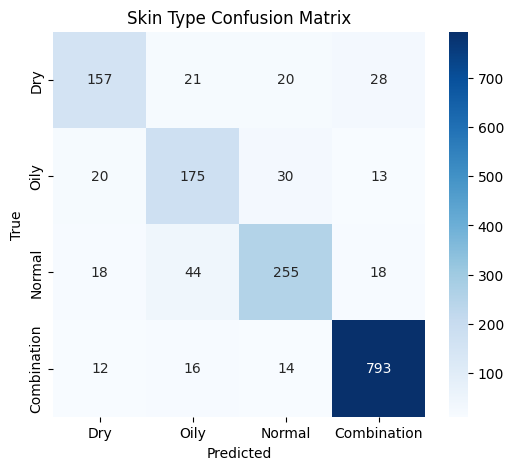

              precision    recall  f1-score   support

         Dry       0.93      0.95      0.94       835
        Oily       0.76      0.69      0.73       226
      Normal       0.80      0.76      0.78       335
 Combination       0.68      0.74      0.71       238

    accuracy                           0.84      1634
   macro avg       0.79      0.79      0.79      1634
weighted avg       0.84      0.84      0.84      1634



In [18]:
# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate_model(df):
    model.eval()
    y_true, y_pred = [], []
    for _, row in df.iterrows():
        y_true.append(INDEX_SKIN[int(row["skin_label"])])
        img = Image.open(row["images"]).convert("RGB")
        img_t = val_transform(crop_face(img)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = model(img_t).argmax(1).item()
        y_pred.append(INDEX_SKIN[pred])

    labels = list(SKIN_LABELS.keys())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title("Skin Type Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    print(classification_report(y_true, y_pred, target_names=labels))

evaluate_model(test_skin)

In [19]:
# =========================================================
# PREDICTION FUNCTION
# =========================================================
def predict_image(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")
    img = crop_face(img)
    img_t = val_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(img_t)
        pred = out.argmax(1).item()

    return INDEX_SKIN[pred]

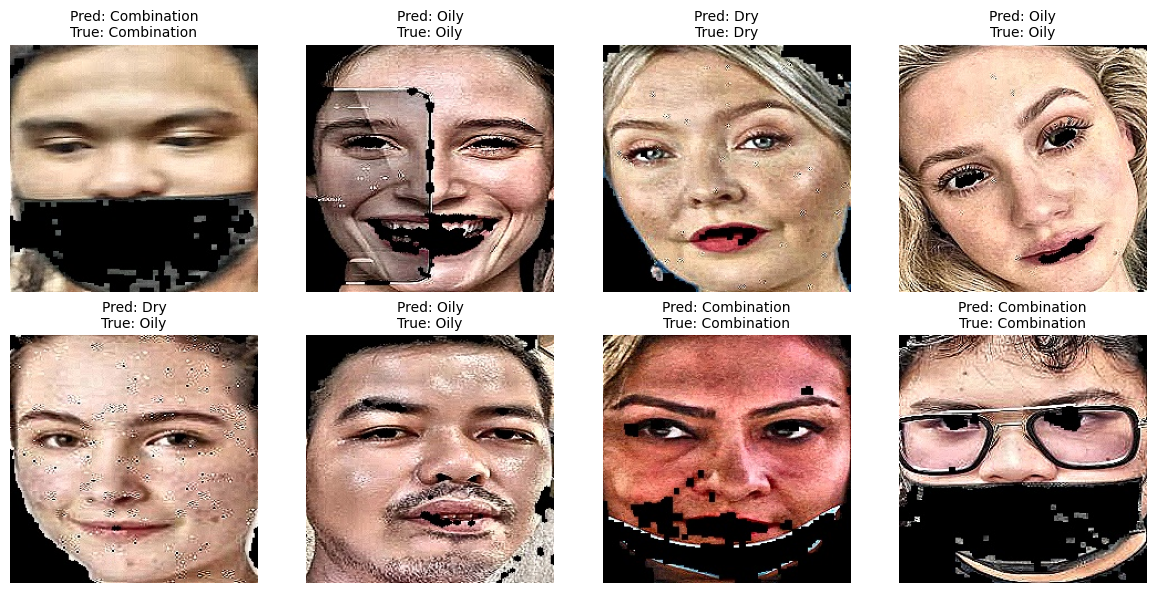

In [20]:
# =========================================================
# DISPLAY SAMPLE PREDICTIONS FOR SKIN
# =========================================================
def display_skin_predictions(df, n=8):
    plt.figure(figsize=(12, 6))
    samples = df.sample(min(n, len(df)), random_state=42)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row["images"]
        img = np.array(Image.open(img_path).convert("RGB"))

        true_label = INDEX_SKIN[int(row["skin_label"])]
        pred_label = predict_image(img_path)

        plt.subplot(2, max(1, len(samples)//2), i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example usage:
display_skin_predictions(test_skin, n=8)

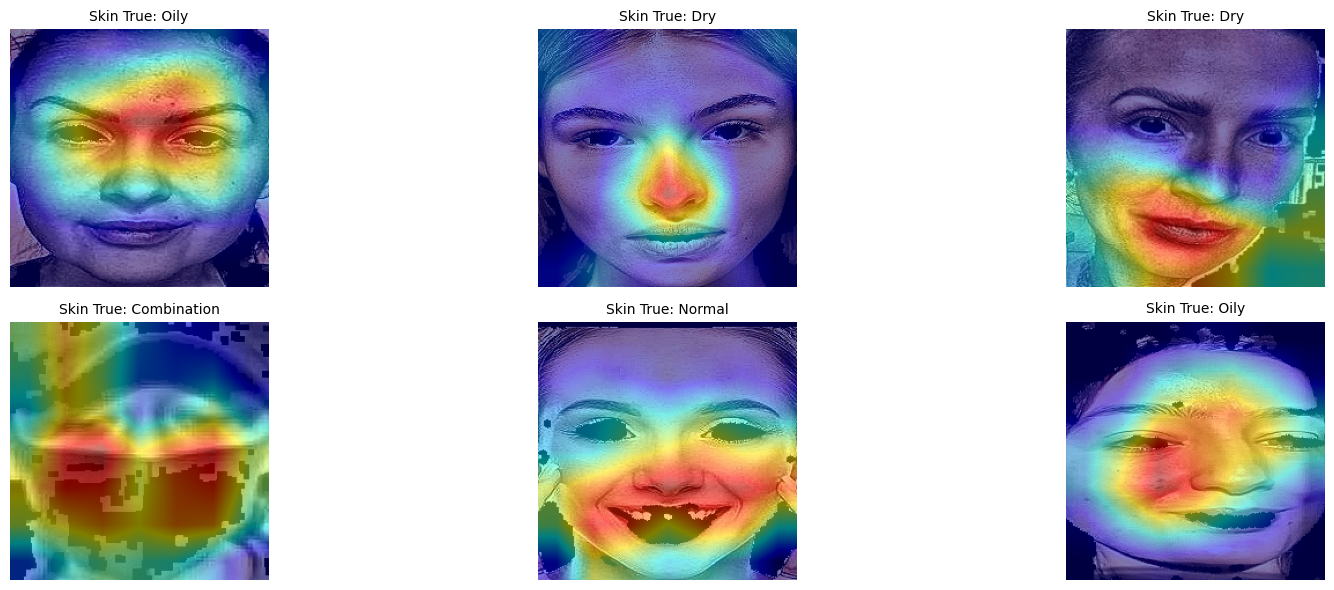

In [21]:
# =========================================================
# GRADCAM ON TRAINING DATA
# =========================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=0, task="skin"):
        self.model.zero_grad()
        input_tensor = input_tensor.unsqueeze(0) if input_tensor.dim() == 3 else input_tensor

        out = self.model(input_tensor)
        score = out[:, class_idx].sum()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam).squeeze().detach().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def show_gradcam(df, task="skin", n=6):
    plt.figure(figsize=(18, 6))
    samples = df.sample(min(n, len(df)), random_state=42)

    target_layer = model.backbone.features[-2]
    gradcam = GradCAM(model, target_layer)

    for i, (_, row) in enumerate(samples.iterrows()):
        img = crop_face(Image.open(row["images"]).convert("RGB"))
        img_resized = cv2.resize(np.array(img), (224, 224))
        input_tensor = val_transform(img).to(DEVICE)

        pred_idx = model(input_tensor.unsqueeze(0)).argmax(1).item()
        cam = gradcam.generate(input_tensor, class_idx=pred_idx)

        heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (0.5 * heatmap + 0.5 * img_resized).astype(np.uint8)

        plt.subplot(2, max(1, len(samples)//2), i + 1)
        plt.imshow(overlay)
        true_label = INDEX_SKIN[int(row["skin_label"])]
        plt.title(f"{task.capitalize()} True: {true_label}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# ===============================
# EXAMPLE USAGE
# ===============================
show_gradcam(train_skin, task="skin", n=6)

In [22]:

# Define the transformation pipeline
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✅ Image transforms defined.")

✅ Image transforms defined.


In [23]:
import cv2
import os
import time
from PIL import Image

def capture_face_image():
    """
    Opens a local camera window with an oval guide.
    Captures the face automatically when aligned.
    """
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    cap = cv2.VideoCapture(0) # Open your laptop's camera
    
    print("Camera opening... Align your face in the oval. Press 'q' to quit.")
    
    captured_pil = None
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Flip frame for natural mirror view
        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape
        center_x, center_y = w // 2, h // 2
        
        # Draw Overlay (Oval Guide)
        overlay = frame.copy()
        cv2.ellipse(overlay, (center_x, center_y), (120, 160), 0, 0, 360, (255, 255, 255), 2)
        cv2.putText(overlay, "Align Face in Oval", (center_x - 100, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Face Detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)
        
        for (x, y, fw, fh) in faces:
            face_cx, face_cy = x + fw // 2, y + fh // 2
            
            # Check alignment
            if abs(face_cx - center_x) < 50 and abs(face_cy - center_y) < 50:
                # Highlight green when aligned
                cv2.ellipse(overlay, (center_x, center_y), (120, 160), 0, 0, 360, (0, 255, 0), 3)
                
                # Capture and Save
                face_crop = frame[y:y+fh, x:x+fw]
                face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
                captured_pil = Image.fromarray(face_rgb)
                
                # Save to disk
                os.makedirs('faces', exist_ok=True)
                cv2.imwrite(f'faces/face_{int(time.time())}.jpg', face_crop)
                
                # Close camera and return
                cap.release()
                cv2.destroyAllWindows()
                print("✅ Face Captured Successfully!")
                return captured_pil

        cv2.imshow('SkinE Face Capture', overlay)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    return captured_pil

In [26]:
# =========================================================
# CAPTURE FACE & PREDICT SKIN TYPE
# =========================================================

# Step 1: Capture face with guided oval camera
img_face = capture_face_image()   # Returns PIL Image of the cropped face

# Step 2: Apply val transforms and run through the model
x = val_transform(img_face).unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    out = model(x)
    pred_label = INDEX_SKIN[out.argmax(1).item()]

print('Predicted Skin Type:', pred_label)


Camera opening... Align your face in the oval. Press 'q' to quit.
✅ Face Captured Successfully!
Predicted Skin Type: Dry
